#### Import Libraries

In [1]:
import pytato as yt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pytato
import inspect
print(f"Package location: {inspect.getfile(pytato)}")
print(f"Package directory: {pytato.__path__}")

Package location: C:\Users\tcoop\AppData\Roaming\Python\Python313\site-packages\pytato\__init__.py
Package directory: ['C:\\Users\\tcoop\\AppData\\Roaming\\Python\\Python313\\site-packages\\pytato']


## Example of Single Enzyme Digestion

### Import Proteome

In [3]:
proteome_df = yt.Silico().import_fasta(source="https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz")

FASTA import complete!


#### (Optional) Add Enzyme

In [4]:
# silico.rules['CL3'] = '(L|Q)(?=S|A|G)'

## Digest Proteome

In [5]:
results = []
silico = yt.Silico()  
silico.missed = 1
peptide_properties_dic = silico.generate_samples(proteome_df,enzyme="thermolysin", target="Peptide", identifier="Gene", pH=7.4, min_charge=0)
peptides_df = pd.DataFrame(peptide_properties_dic)



Proteolysis using thermolysin underway.
Generating peptides...
Generated 1025123 peptides matching criteria.


In [6]:
peptides_df.head()

,Gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z
0,THSD8,ILGPWGKWRC,10,"{'I': 1, 'P': 1, 'G': 2, 'K': 1, 'R': 1, 'L': ...",2,2,1196.627705,-0.180000,598.313852
1,THSD8,LGPWGKWRC,9,"{'P': 1, 'G': 2, 'K': 1, 'R': 1, 'L': 1, 'W': ...",2,2,1083.543641,-0.700000,541.771820
2,THSD8,LGPWGKWRCLCD,12,"{'P': 1, 'G': 2, 'K': 1, 'R': 1, 'L': 2, 'W': ...",1,1,1414.663833,-0.291667,1414.663833
3,THSD8,LCDLGKQERSRE,12,"{'G': 1, 'K': 1, 'R': 2, 'S': 1, 'L': 2, 'Q': ...",0,0,1413.714682,-1.500000,NaN
4,THSD8,LGKQERSRE,9,"{'G': 1, 'K': 1, 'R': 2, 'S': 1, 'L': 1, 'Q': ...",1,1,1082.594490,-2.311111,1082.594490


#### Determine number of peptides per gene

In [7]:
print(len(peptides_df))
peptides_df = peptides_df[peptides_df['z'] <= 6]
print(len(peptides_df))
peptide_counts = peptides_df.groupby('Gene').size()
print(peptide_counts)

1025123
1020404
Gene
1433B     21
1433E     15
1433F     20
1433G     18
1433S     11
        ... 
ZY11A     46
ZY11B     44
ZYX       71
ZZEF1    216
ZZZ3      69
Length: 20599, dtype: int64


#### Peptide Properties

In [8]:
# yt.Plots.petide_hex()

<Figure size 500x400 with 0 Axes>

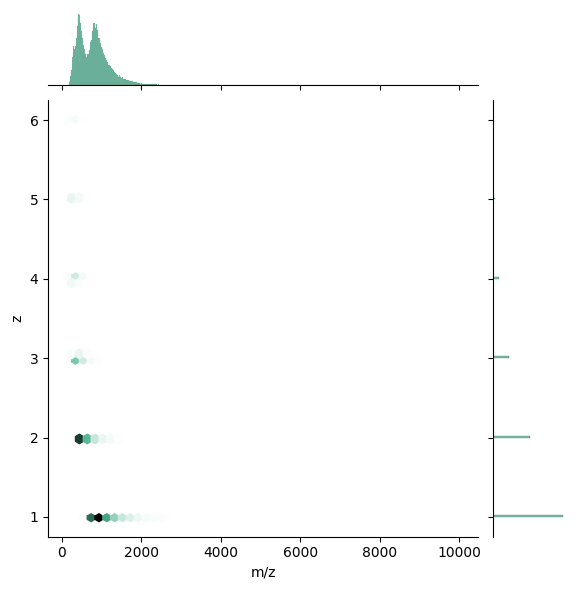

In [14]:
x = peptides_df['m/z']
y = peptides_df['z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")


plt.show()

1020404
742165
167468


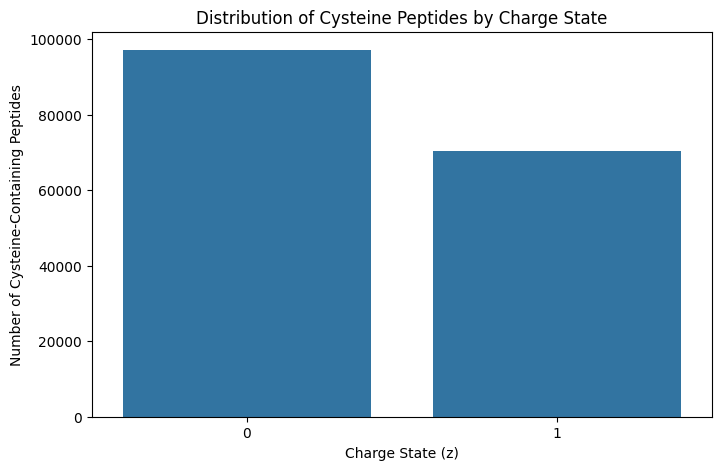

In [15]:
## need to filter for protiens with z = 1
## need to filter for peptides with Cysteiine

# Filter for peptides with charge state z=1
z_peptides = peptides_df[peptides_df['z'] <= 1]
cys_peptides = z_peptides[z_peptides['peptide'].str.contains('C')]

print(len(peptides_df))
print(len(z_peptides))
print(len(cys_peptides))

#I want to make a bar graph where x is the z and y is the number of peptides containing cysteine

# Count peptides containing cysteine for each charge state
cys_by_charge = cys_peptides['z'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=cys_by_charge.index, y=cys_by_charge.values)
plt.xlabel('Charge State (z)')
plt.ylabel('Number of Cysteine-Containing Peptides')
plt.title('Distribution of Cysteine Peptides by Charge State')
plt.show()



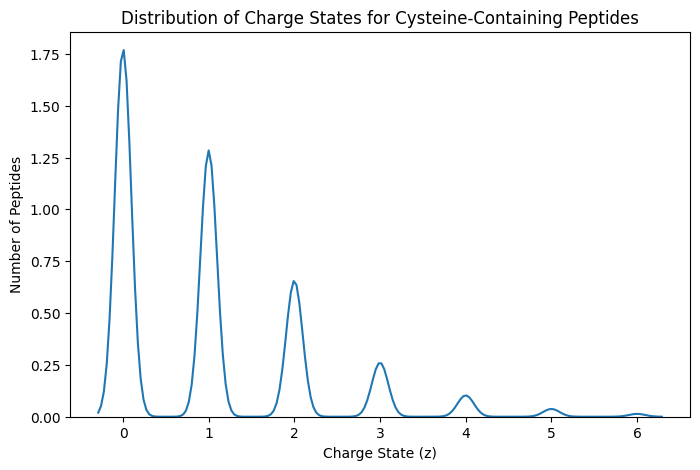

In [16]:
#using the cys_peptides dataframe, I want to make distrbution plot where z is on the x axis and the number of peptides is on the y axis
cys_peptides = peptides_df[peptides_df['peptide'].str.contains('C')]
plt.figure(figsize=(8,5))
sns.kdeplot(data=cys_peptides, x='z')
plt.xlabel('Charge State (z)')
plt.ylabel('Number of Peptides')
plt.title('Distribution of Charge States for Cysteine-Containing Peptides')
plt.show()



In [17]:
# using the peptides_df dataframe, I want to add 105.0578 to the m/z column and +1 to the z column for every C that is in the peptide sequence.
# I would like to make a new dataframe with the modified peptides_df    
# Create new dataframe for modified peptides
modified_peptides_df = peptides_df.copy()

# Count number of cysteines in each peptide
modified_peptides_df['C_count'] = modified_peptides_df['peptide'].str.count('C')

# Add mass shift and charge for each cysteine
modified_peptides_df['m/z'] = modified_peptides_df.apply(lambda x: x['m/z'] + (105.0578 * x['C_count']) if pd.notnull(x['m/z']) else x['m/z'], axis=1)
modified_peptides_df['z'] = modified_peptides_df['z'] + modified_peptides_df['C_count']

# Drop the temporary C_count column
modified_peptides_df.drop('C_count', axis=1, inplace=True)





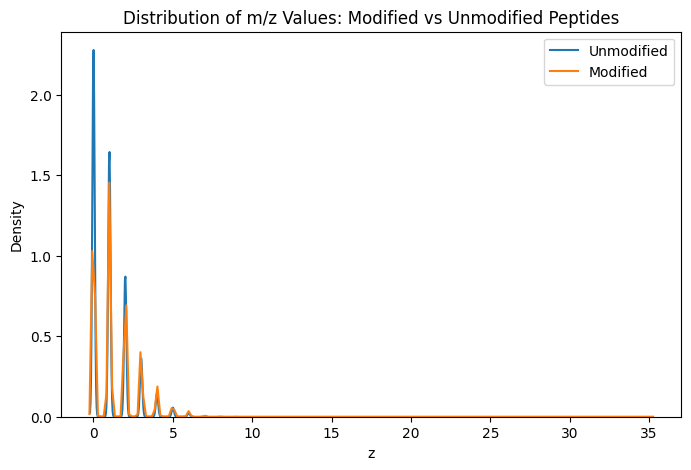

In [18]:

plt.figure(figsize=(8,5))
sns.kdeplot(data=peptides_df, x='z', label='Unmodified', common_norm=True)
sns.kdeplot(data=modified_peptides_df, x='z', label='Modified', common_norm=True)
plt.xlabel('z')
plt.ylabel('Density')
plt.title('Distribution of m/z Values: Modified vs Unmodified Peptides')
plt.legend()
plt.show()



